In [1]:
using StatsPlots
using DataFrames
using CSV
using LaTeXStrings

In [2]:
function δ_bound_improvement(inst, target)
    if isinf(inst.initial_δ_bound) || isinf(inst.final_δ_bound)
        return 0.0
    end
    clamp(ifelse(inst.status .!= "UNKNOWN", 1.0, (inst.initial_δ_bound - inst.final_δ_bound) / (inst.initial_δ_bound - target)), 0.0, 1.0)
end

δ_bound_improvement (generic function with 1 method)

In [59]:
curr_dir = @__DIR__
exp_final_dir = joinpath(curr_dir, "..", "experiments_final")

base_dir = exp_final_dir

acas_name = "acas-0.05-120"
mnist_name = "mnist-1.0-120"

eval_acas_dir = joinpath(base_dir, "eval_acas")
eval_mnist_dir = joinpath(base_dir, "eval_mnist")

# mkdir(eval_acas_dir)
# mkdir(eval_mnist_dir)

results_file = "results.csv"
csv_title = ["net", "spec", "status", "runtime", "num_propagation", "num_input_splits", "num_neuron_splits", "initial_δ_bound", "final_δ_bound"]

heuristic_variants = "DU" .* ["", "-Input-DiffZono"]
# configs = ["LP", "LP-ZC", "VS", "ZC-Inter", "ZC-Post", "ZC"]
configs = ["LP", "LP-ZC"]
configs = mapreduce(c -> c * "-" .* heuristic_variants, vcat, configs)
configs = vcat(configs, "VeryDiff")
# configs = mapreduce(c -> c .* ["", "-SB", "-DB", "-SB-DB"], vcat, configs)
configs = mapreduce(c -> c .* ["", "-RS-SB", "-RS-DB", "-RS-SB-DB"], vcat, configs)
neuron_splitting_cfgs = filter(c -> !contains(c, "Input"), configs)
input_splitting_cfgs = filter(c -> contains(c, "VeryDiff") || contains(c, "Input"), configs)
all_configs = zip(["Neuron Splitting", "Neuron + Input Splitting"], [neuron_splitting_cfgs, input_splitting_cfgs])

configs_paths = Dict(c => joinpath(base_dir, c) for c in configs)
acas_paths = Dict(c => joinpath(configs_paths[c], acas_name, results_file) for c in configs)
mnist_paths = Dict(c => joinpath(configs_paths[c], mnist_name, results_file) for c in configs)

println("...")

...


In [60]:
cfgs_names = Dict(c => replace(c, 
        r"\-*(Base|Input|DiffZono|DU)" => "", 
        "DeepSplit" => "LP", 
        "VerticalSplitting" => "VS", 
        "ZonoContract" => "ZC", 
        # "Inter" => "-Inter",
        # "Post" => "-Post",
        # "SB" => "",
        # "DB" => "",
    ) for c in configs)

Dict{String, String} with 20 entries:
  "VeryDiff-RS-SB"                   => "VeryDiff-RS-SB"
  "LP-DU"                            => "LP"
  "LP-ZC-DU-RS-DB"                   => "LP-ZC-RS-DB"
  "LP-ZC-DU-Input-DiffZono"          => "LP-ZC"
  "LP-DU-Input-DiffZono-RS-SB"       => "LP-RS-SB"
  "LP-ZC-DU-RS-SB-DB"                => "LP-ZC-RS-SB-DB"
  "LP-ZC-DU-Input-DiffZono-RS-SB"    => "LP-ZC-RS-SB"
  "LP-DU-RS-DB"                      => "LP-RS-DB"
  "LP-DU-Input-DiffZono-RS-SB-DB"    => "LP-RS-SB-DB"
  "VeryDiff"                         => "VeryDiff"
  "LP-ZC-DU-Input-DiffZono-RS-SB-DB" => "LP-ZC-RS-SB-DB"
  "VeryDiff-RS-DB"                   => "VeryDiff-RS-DB"
  "LP-ZC-DU"                         => "LP-ZC"
  "LP-DU-RS-SB-DB"                   => "LP-RS-SB-DB"
  "LP-ZC-DU-Input-DiffZono-RS-DB"    => "LP-ZC-RS-DB"
  "VeryDiff-RS-SB-DB"                => "VeryDiff-RS-SB-DB"
  "LP-DU-RS-SB"                      => "LP-RS-SB"
  "LP-DU-Input-DiffZono-RS-DB"       => "LP-RS-DB"
  "LP-ZC

In [61]:
mnist_data = Dict(c => CSV.read(mnist_paths[c], DataFrame, header=csv_title, delim=", ") for c in configs)

Dict{String, DataFrame} with 20 entries:
  "VeryDiff-RS-SB"                   => 160×9 DataFrame…
  "LP-DU"                            => 160×9 DataFrame…
  "LP-ZC-DU-RS-DB"                   => 160×9 DataFrame…
  "LP-ZC-DU-Input-DiffZono"          => 160×9 DataFrame…
  "LP-DU-Input-DiffZono-RS-SB"       => 160×9 DataFrame…
  "LP-ZC-DU-RS-SB-DB"                => 160×9 DataFrame…
  "LP-ZC-DU-Input-DiffZono-RS-SB"    => 160×9 DataFrame…
  "LP-DU-RS-DB"                      => 160×9 DataFrame…
  "LP-DU-Input-DiffZono-RS-SB-DB"    => 160×9 DataFrame…
  "VeryDiff"                         => 160×9 DataFrame…
  "LP-ZC-DU-Input-DiffZono-RS-SB-DB" => 160×9 DataFrame…
  "VeryDiff-RS-DB"                   => 160×9 DataFrame…
  "LP-ZC-DU"                         => 160×9 DataFrame…
  "LP-DU-RS-SB-DB"                   => 160×9 DataFrame…
  "LP-ZC-DU-Input-DiffZono-RS-DB"    => 160×9 DataFrame…
  "VeryDiff-RS-SB-DB"                => 160×9 DataFrame…
  "LP-DU-RS-SB"                      => 160×9 D

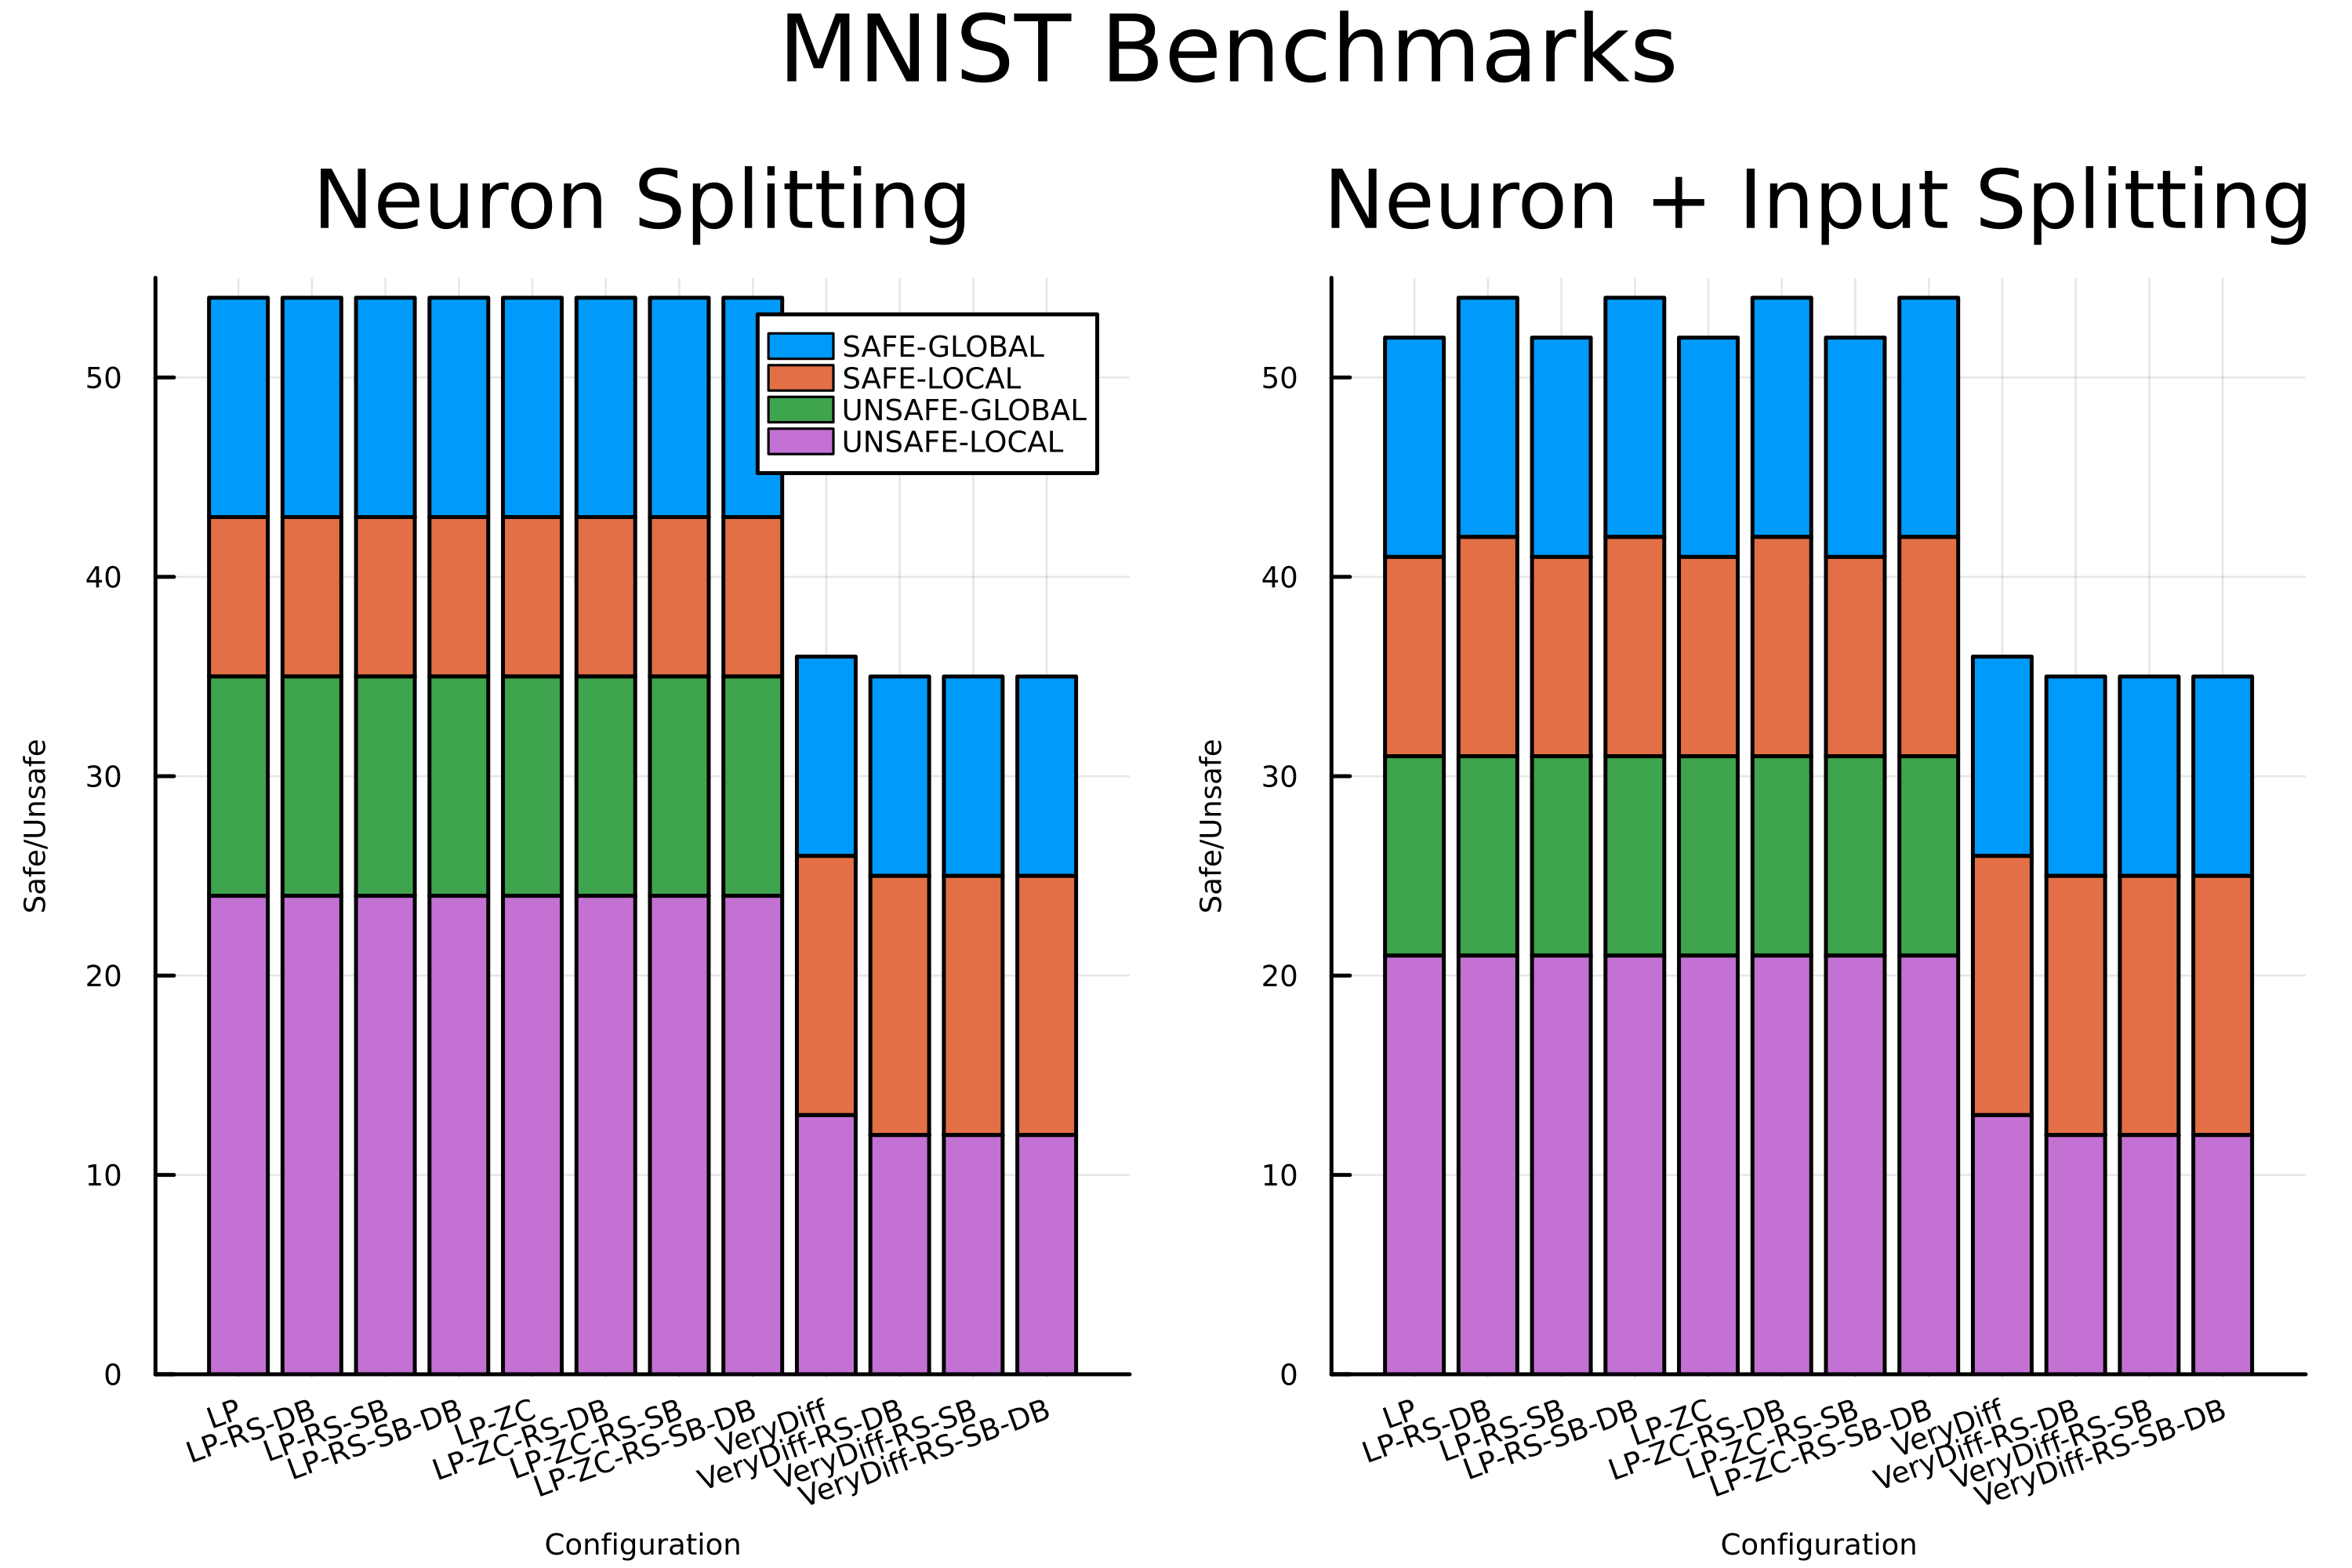

In [62]:
p = plot(dpi=500, widen=true, legend=false, xlabel="Configuration", ylabel="Safe/Unsafe"; layout=2)
max_y = 0
for (i, (name, configs)) in enumerate(all_configs)
    df = DataFrame()
    temp = DataFrame()
    for config in configs
        # temp = transform(mnist_data[config], :status => "group")
        temp = transform(mnist_data[config], [:status, :spec] => ByRow((x, y) -> ifelse(contains(y, "local"), "$x-LOCAL", "$x-GLOBAL")) => "group")
        temp = combine(groupby(temp, :group), nrow => :count)
        temp = temp[.!(contains.(temp.group, "UNKNOWN")), :]
        # temp = temp[.!(contains.(temp.group, "UNSAFE")), :]
        # temp = temp[(contains.(temp.group, "LOCAL")), :]
        # temp = temp[(contains.(temp.group, "GLOBAL")), :]
        temp[!, "config"] .= config
        df = vcat(df, temp)
        max_y = max(max_y, sum(temp.count))
    end
    # max_y = max(max_y, maximum(df.count))
    names = map(c -> cfgs_names[c], df.config)
    groupedbar!(names, df.count, group=df.group, bar_position=:stack, title=name, subplot=i)
end
plot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)
plot!(p, guidefontsize=5, tickfontsize=5, xrotation=20)
plot!(p, legend=:best, legendfontsize=5, subplot=1)
plot!(p, ylims=(0, max_y+1))

# savefig(p, "$eval_mnist_dir/$(mnist_name)-hist.pdf")
savefig(p, "$eval_mnist_dir/row_subst/$(mnist_name)-hist.pdf")
# savefig(p, "$eval_mnist_dir/split_diff_bounds/$(mnist_name)-hist.pdf")

p

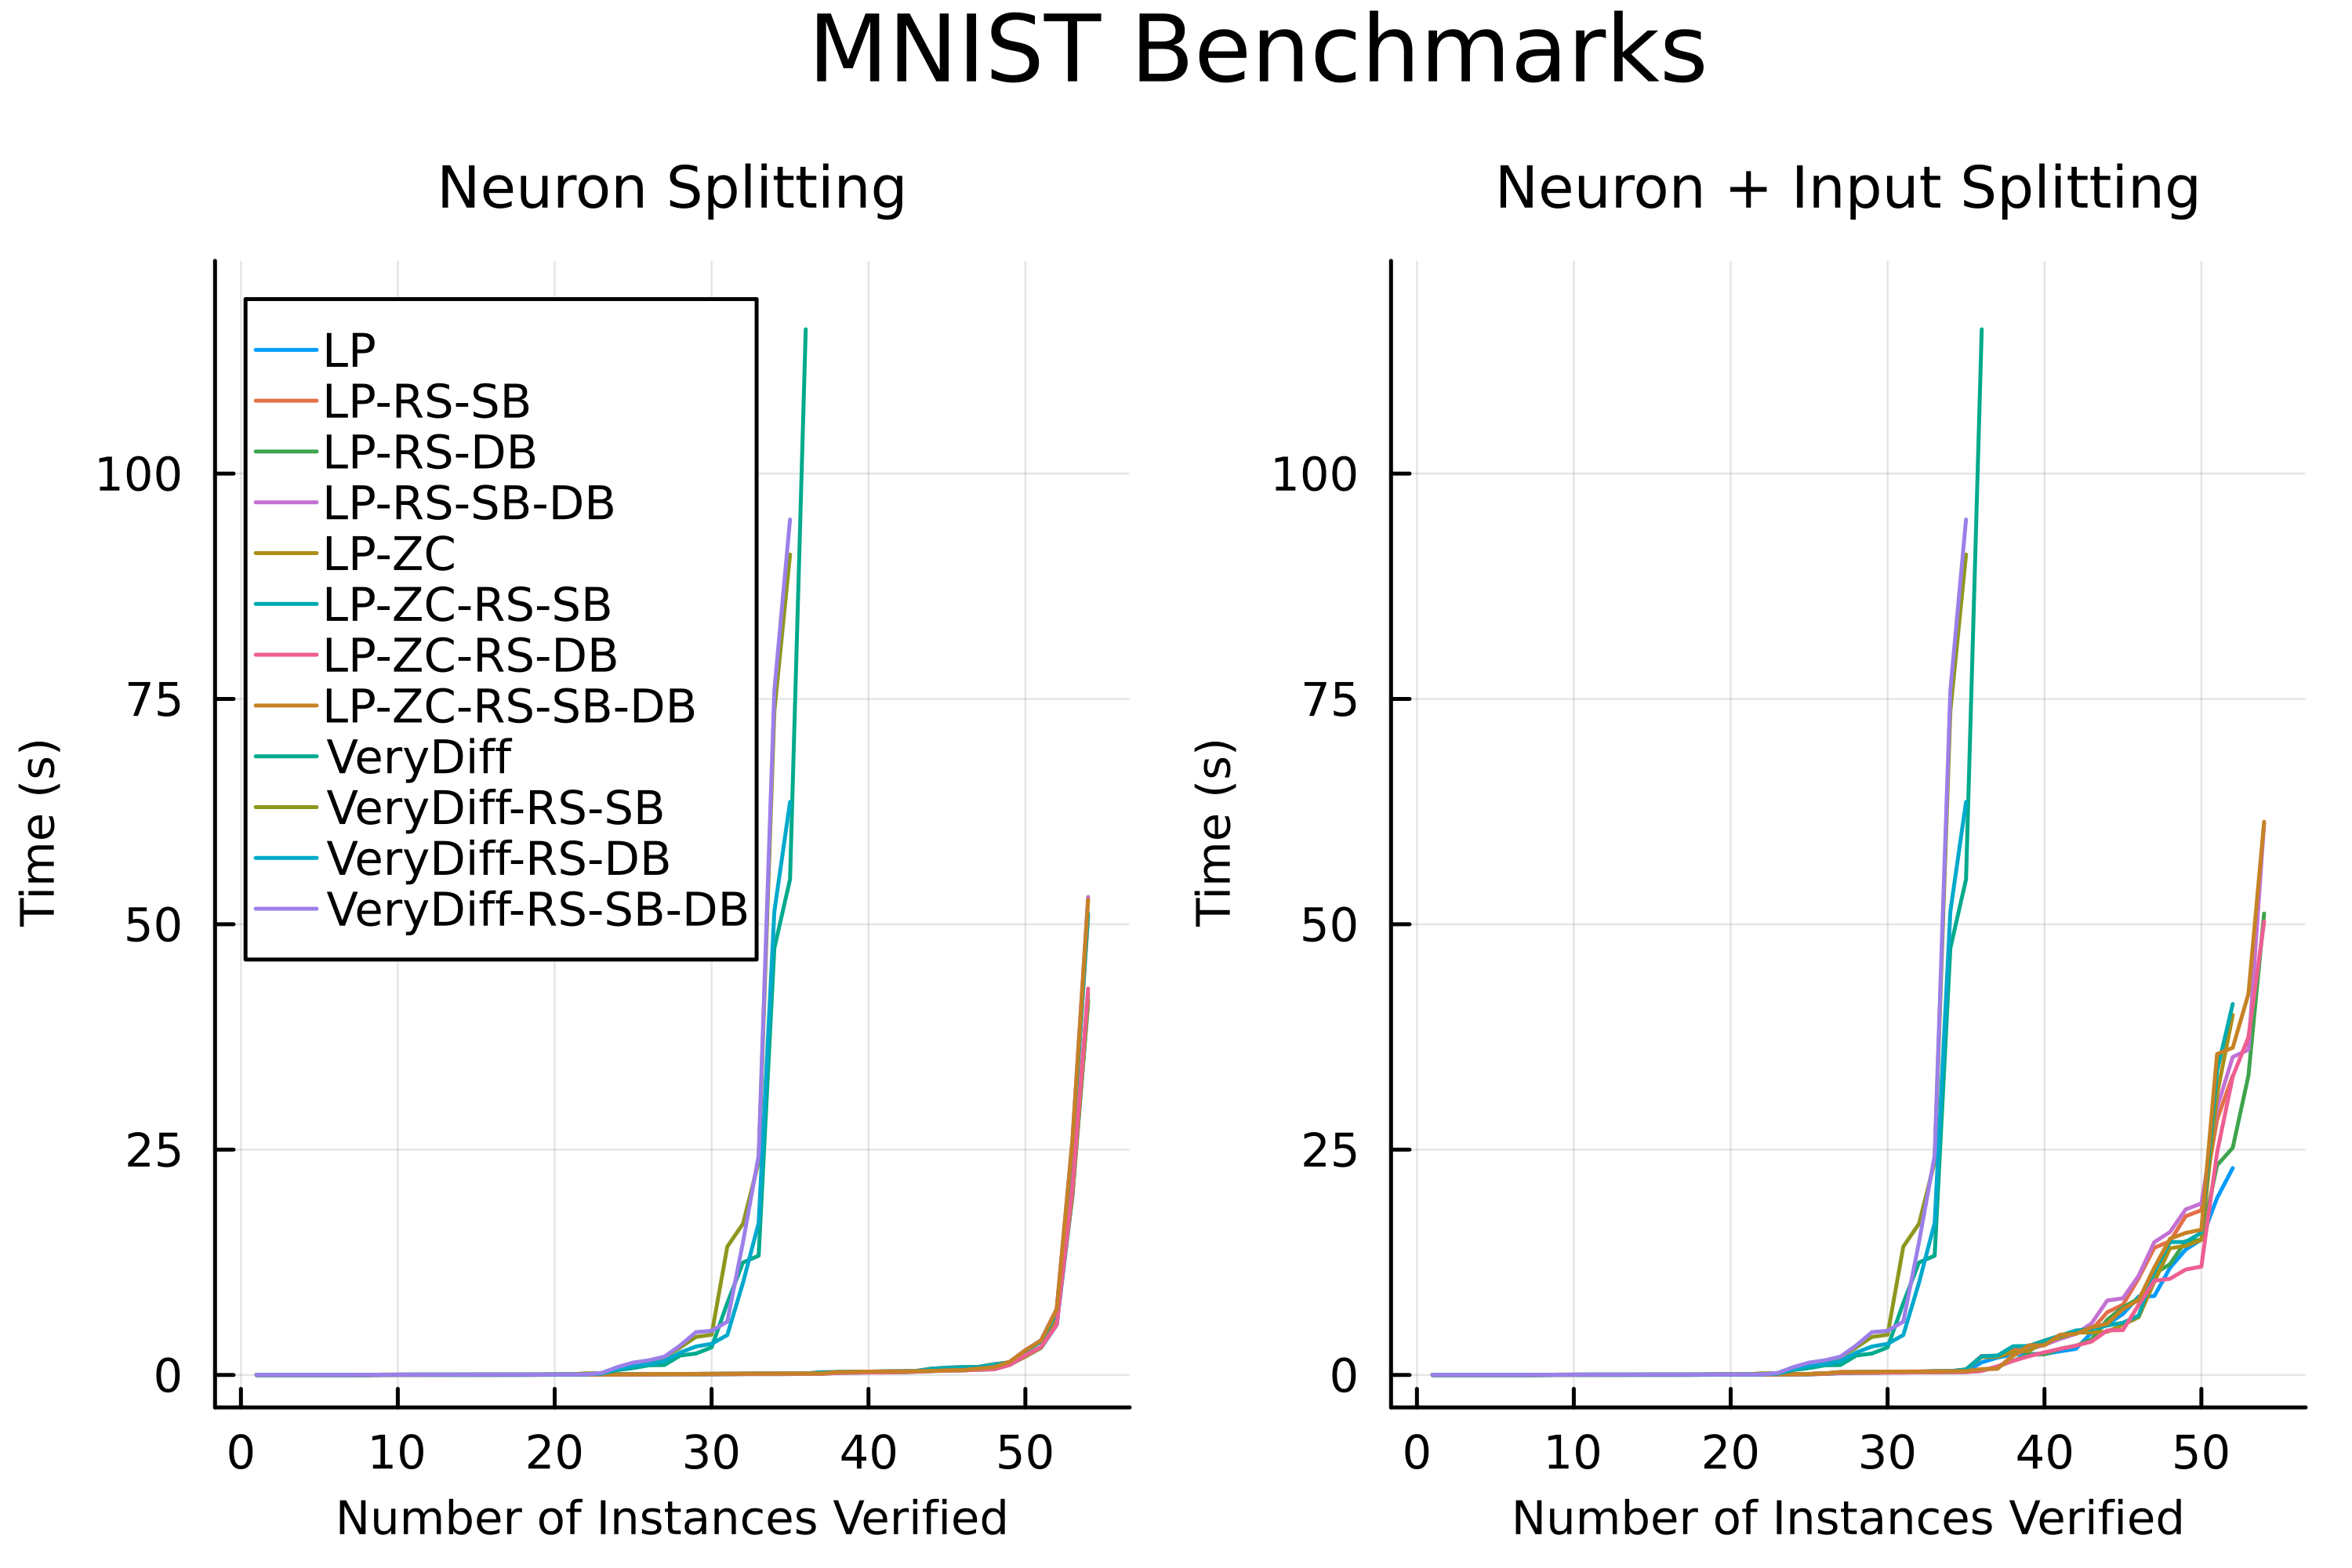

In [63]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 55), ylims=(0, 120), widen=true, titlefontsize=10, xguidefontsize=8, yguidefontsize=8, legend=false; layout=2)
xlabel!("Number of Instances Verified")
ylabel!("Time (s)")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    runtimes = map(c -> c.runtime / 1e9, filter.(c -> c.status != "UNKNOWN", map(c -> mnist_data[c], cfgs)))
    runtimes = sort.(runtimes)
    for (j, runtime) in enumerate(runtimes)
        plot!(p, runtime, title=titles[i], label=cfgs_names[cfgs[j]], subplot=i)
    end
end

plot!(p, subplot=1, legend=:topleft)
plot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)

# savefig(p, "$eval_mnist_dir/$(mnist_name).pdf")
savefig(p, "$eval_mnist_dir/row_subst/$(mnist_name).pdf")
# savefig(p, "$eval_mnist_dir/split_diff_bounds/$(mnist_name).pdf")

p

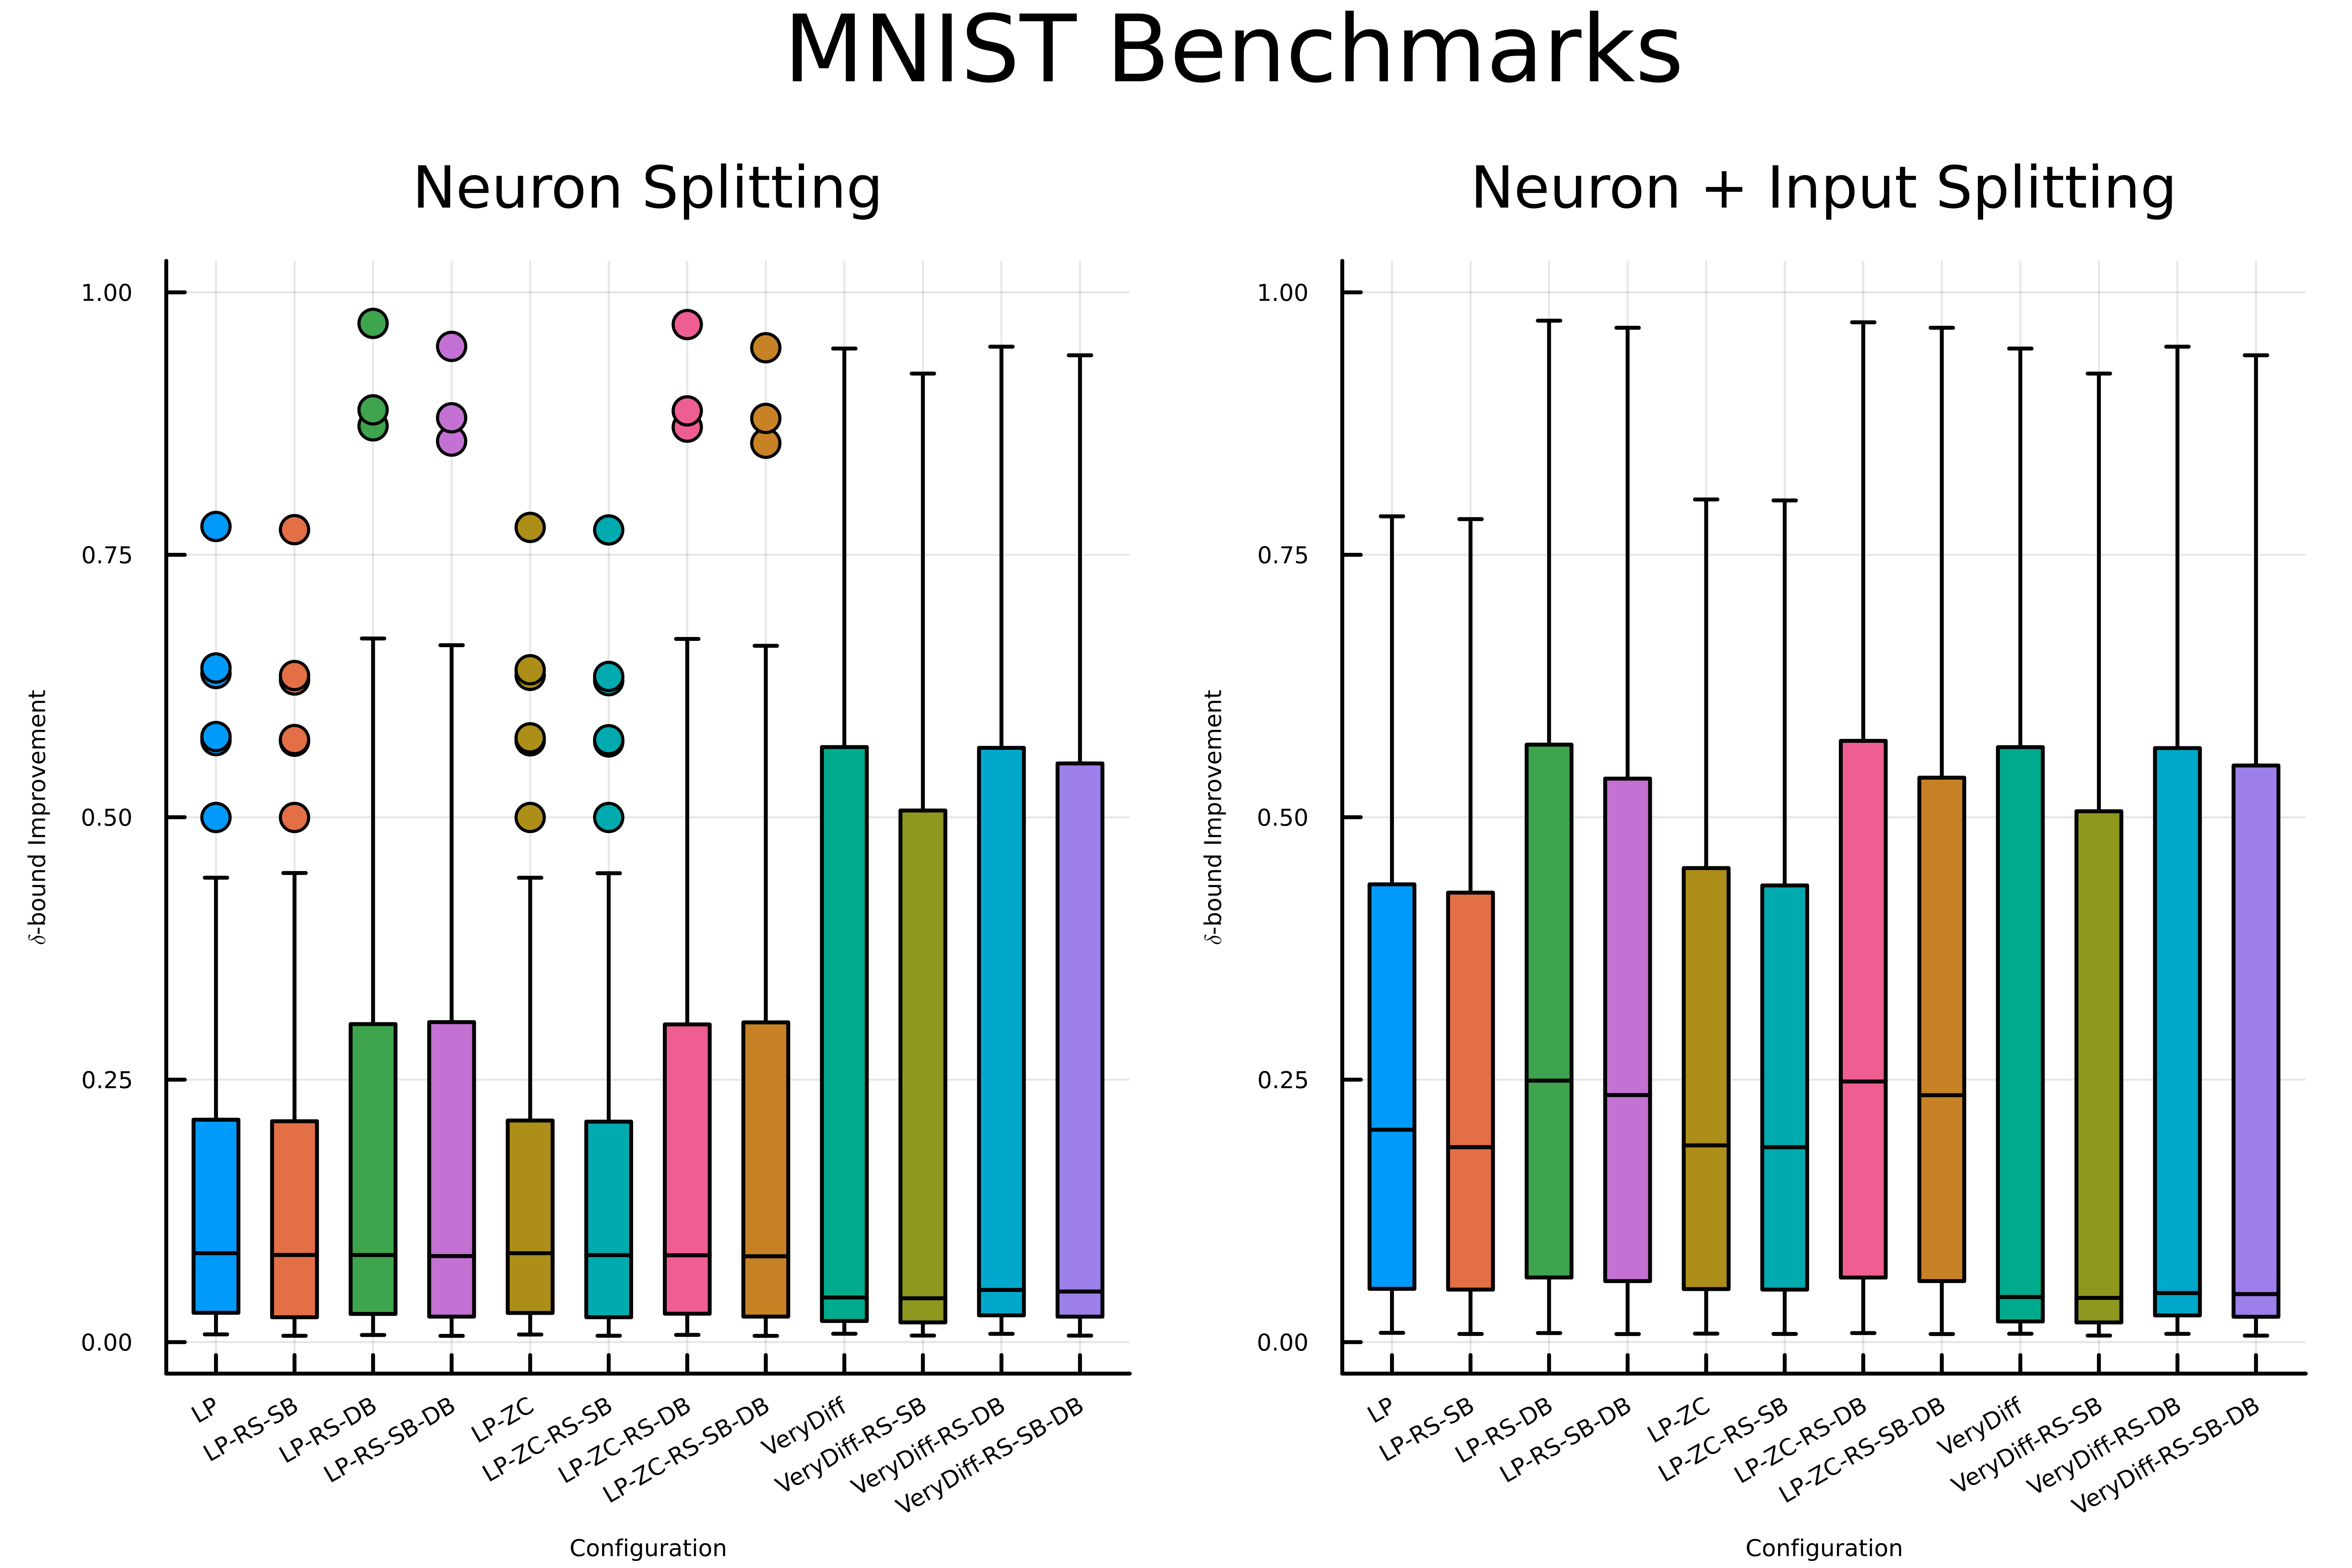

In [64]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
num_cfgs = size(all_cfgs, 1)
p = boxplot(dpi=1000, widen=true, titlefontsize=10, xguidefontsize=5, yguidefontsize=5, legend=false; layout=num_cfgs)
xlabel!("Configuration")
ylabel!(L"δ" * "-bound Improvement")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    unsolved_mask = mapfoldl(c -> mnist_data[c].status .== "UNKNOWN", (x, y) -> x .&& y, cfgs)
    improvements = mapreduce(cfg -> sort(δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfg][unsolved_mask, :]), 1.0)), hcat, cfgs)
    boxplot!(p, mapreduce(c -> cfgs_names[c], hcat, cfgs), improvements, title=titles[i], subplot=i)
end

ylims!(0, 1)
boxplot!(p, subplot=1, legend=false)
boxplot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)
plot!(p, guidefontsize=4, tickfontsize=4, xrotation=30)
# plot!(p, legend=:topright, legendfontsize=5, subplot=1)

# savefig(p, "$eval_mnist_dir/$(mnist_name)-boxplot.pdf")
savefig(p, "$eval_mnist_dir/row_subst/$(mnist_name)-boxplot.pdf")
# savefig(p, "$eval_mnist_dir/split_diff_bounds/$(mnist_name)-boxplot.pdf")

p

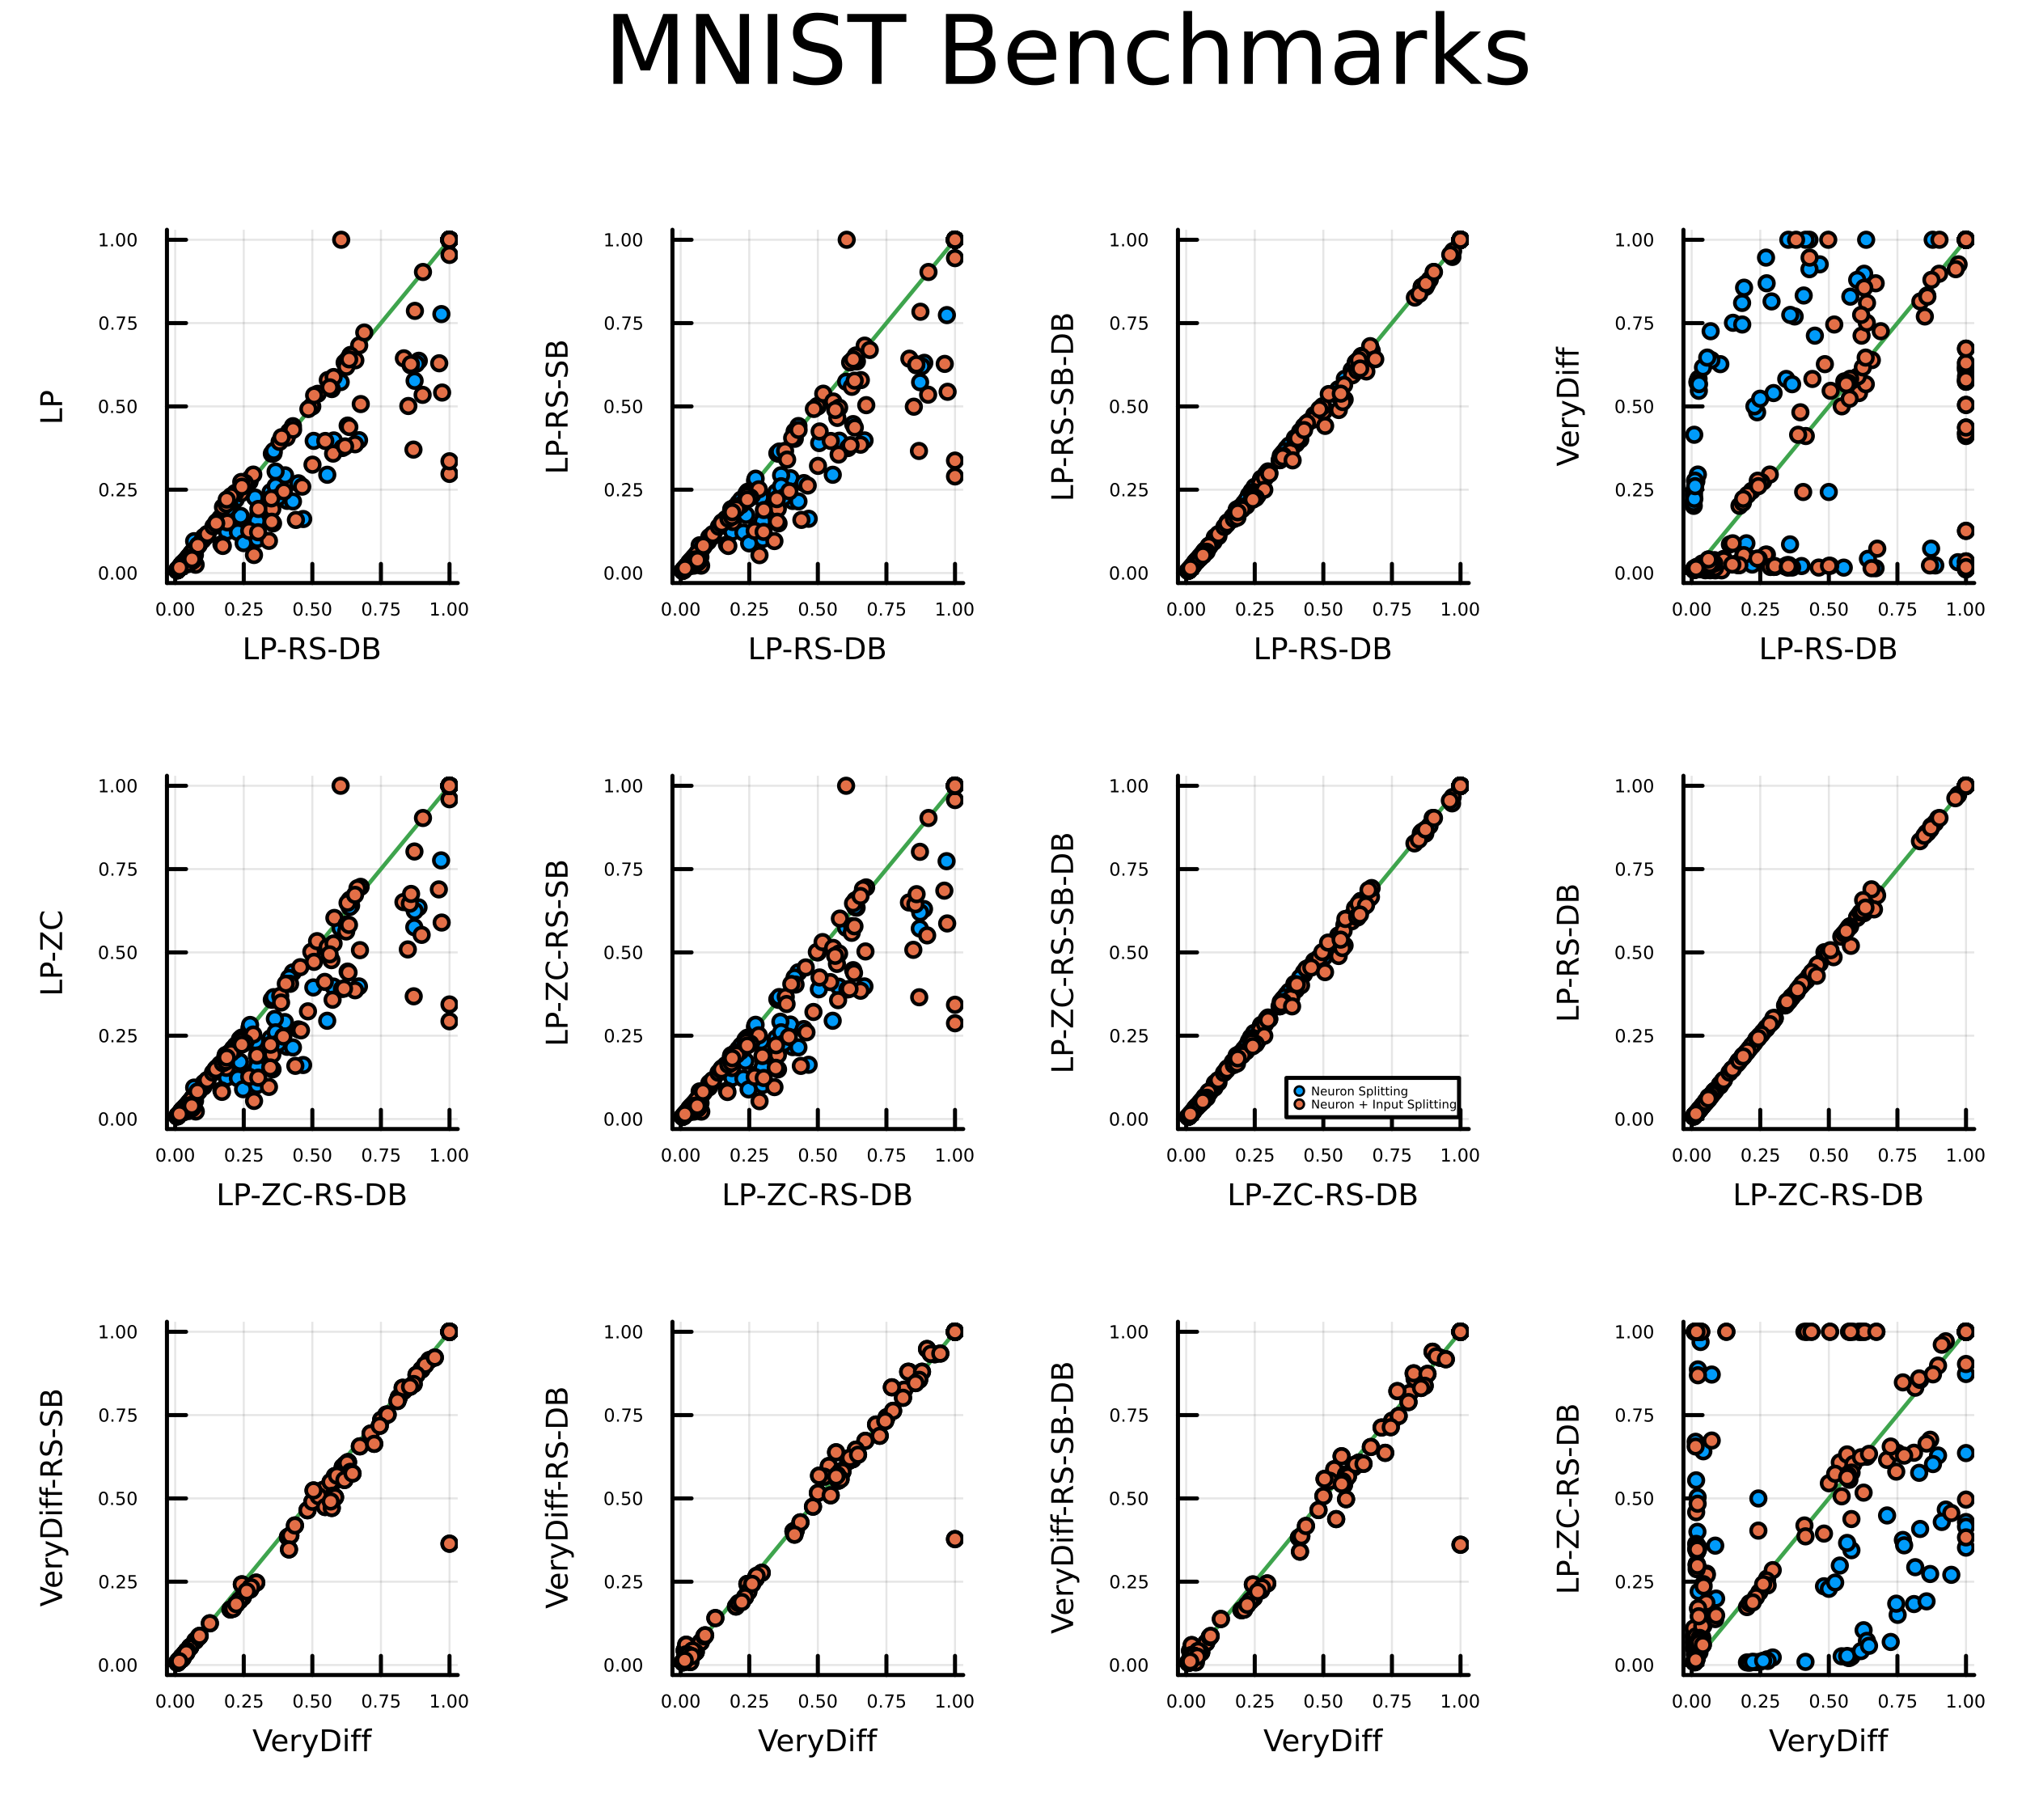

In [65]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 1), ylims=(0, 1), widen=true, legend=false, label=false; layout=grid(3, 4), size=(500, 450))

labels = ["Neuron Splitting" "Neuron + Input Splitting"]
# combinations = [(2, 1), (3, 2), (6, 2), (2, 7), (3, 7), (6, 7), (4, 6), (3, 6), (5, 6)]
# combinations = [(2, 1), (3, 1), (3, 7), (5, 4), (6, 4), (6, 3), (8, 7), (9, 7), (6, 7)]
combinations = [(3, 1), (3, 2), (3, 4), (3, 9), (7, 5), (7, 6), (7, 8), (7, 3), (9, 10), (9, 11), (9, 12), (9, 7)]

for (n, (i, j)) in enumerate(combinations)
    plot!(p, range(0, 1), range(0, 1), label=false, c=3, subplot=n)

    for (k, cfgs) in enumerate(all_cfgs)
        xlabel!(cfgs_names[cfgs[i]], subplot=n)
        ylabel!(cfgs_names[cfgs[j]], subplot=n)
        
        y₁ = δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfgs[i]]), 1.0)
        y₂ = δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfgs[j]]), 1.0)

        scatter!(p, y₁, y₂, markersize=2.0, label=labels[k], c=k, subplot=n)
    end
end

scatter!(p, subplot=7, label=labels, legend=:bottomright)
plot!(p, guidefontsize=5, tickfontsize=3, legendfontsize=2)
plot!(p, plot_title="MNIST Benchmarks", plot_titlevspan=0.1)

# savefig(p, "$eval_mnist_dir/$(mnist_name)-bounds.pdf")
savefig(p, "$eval_mnist_dir/row_subst/$(mnist_name)-bounds.pdf")
# savefig(p, "$eval_mnist_dir/split_diff_bounds/$(mnist_name)-bounds.pdf")

p

In [ ]:
acas_data = Dict(c => CSV.read(acas_paths[c], DataFrame, header=csv_title, delim=", ") for c in configs)

In [ ]:
p = plot(dpi=500, widen=true, legend=false, xlabel="Configuration", ylabel="Safe/Unsafe"; layout=2)
max_y = 0
for (i, (name, configs)) in enumerate(all_configs)
    df = DataFrame()
    temp = DataFrame()
    for config in configs
        temp = transform(acas_data[config], :status => "group")
        temp = combine(groupby(temp, :group), nrow => :count)
        temp = temp[.!(contains.(temp.group, "UNKNOWN")), :]
        temp[!, "config"] .= config
        df = vcat(df, temp)
    end
    names = map(c -> cfgs_names[c], df.config)
    max_y = max(max_y, maximum(df.count))
    groupedbar!(names, df.count, group=df.group, bar_position=:dodge, title=name, subplot=i)
end
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
plot!(p, legend=:best, legendcolumns=2, subplot=1)
plot!(p, ylims=(0, max_y+10))

savefig(p, "$eval_acas_dir/$(acas_name)-hist.pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 100), ylims=(0, 120), widen=true, titlefontsize=10, xguidefontsize=8, yguidefontsize=8, legend=false; layout=2)
xlabel!("Number of Instances Verified")
ylabel!("Time (s)")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    runtimes = map(c -> c.runtime / 1e9, filter.(c -> c.status != "UNKNOWN", map(c -> acas_data[c], cfgs)))
    runtimes = sort.(runtimes)
    for (j, runtime) in enumerate(runtimes)
        plot!(p, runtime, title=titles[i], label=cfgs_names[cfgs[j]], subplot=i)
    end
end

plot!(p, subplot=1, legend=:topleft)
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name).pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
num_cfgs = size(all_cfgs, 1)
p = boxplot(dpi=500, widen=true, titlefontsize=10, xguidefontsize=5, yguidefontsize=5, legend=false; layout=num_cfgs)
xlabel!("Configuration")
ylabel!(L"δ" * "-bound Improvement")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    unsolved_mask = mapfoldl(c -> acas_data[c].status .== "UNKNOWN", (x, y) -> x .&& y, cfgs)
    improvements = mapreduce(cfg -> sort(δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfg][:, :]), 0.05)), hcat, cfgs)
    boxplot!(p, mapreduce(c -> cfgs_names[c], hcat, cfgs), improvements, title=titles[i], subplot=i)
end

ylims!(0, 1)
boxplot!(p, subplot=1, legend=false)
boxplot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
boxplot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name)-boxplot.pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 1), ylims=(0, 1), widen=true, legend=false, label=false; layout=grid(3, 3), size=(500, 450))

labels = ["Neuron Splitting" "Neuron + Input Splitting"]
combinations = [(2, 1), (3, 2), (6, 2), (2, 7), (3, 7), (6, 7), (4, 6), (3, 6), (5, 6)]

for (n, (i, j)) in enumerate(combinations)
    plot!(p, range(0, 1), range(0, 1), label=false, c=3, subplot=n)

    for (k, cfgs) in enumerate(all_cfgs)
        xlabel!(cfgs_names[cfgs[i]], subplot=n)
        ylabel!(cfgs_names[cfgs[j]], subplot=n)
        
        y₁ = δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfgs[i]]), 0.05)
        y₂ = δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfgs[j]]), 0.05)

        scatter!(p, y₁, y₂, markersize=2.0, label=labels[k], c=k, subplot=n)
    end
end

scatter!(p, subplot=7, label=labels, legend=:bottomright)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5, ytickfontsize=5, legendfontsize=3)
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name)-bounds.pdf")

p